**24BAD130 Vishal S**

**SCENARIO 1: **
Predict ocean water temperature using environmental and depth-related features.
Dataset (Kaggle – Public):
https://www.kaggle.com/datasets/sohier/calcofi
Target Variable:
•	Water Temperature (T_degC)
Sample Input Features
•	Depth (m)
•	Salinity
•	Oxygen
•	Latitude
•	Longitude

IN-LAB TASKS
•	Import necessary Python libraries (NumPy, Pandas, Matplotlib, Seaborn, Scikit-learn).
•	Load the CalCOFI dataset into a Pandas DataFrame
•	Select relevant numerical features and target variable.
•	Handle missing values using mean/median imputation.
•	Perform feature scaling using StandardScaler.
•	Split the dataset into training and testing sets.
•	Train a Linear Regression model using Scikit-learn.
•	Predict water temperature for test data.
•	Evaluate model performance using:
– Mean Squared Error (MSE)
– Root Mean Squared Error (RMSE)
– R² Score
•	Visualize:
– Actual vs Predicted temperature
– Residual errors
•	Optimize model performance using:
– Feature selection
– Regularization (Ridge / Lasso)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
print("Vishal S 24BAD130")
bottle_df = pd.read_csv("bottle.csv")
cast_df = pd.read_csv("cast.csv")

Vishal S 24BAD130


In [ ]:
bottle_df.head()

,Cst_Cnt,Btl_Cnt,Sta_ID,Depth_ID,Depthm,T_degC,Salnty,O2ml_L,STheta,O2Sat,...,R_PHAEO,R_PRES,R_SAMP,DIC1,DIC2,TA1,TA2,pH2,pH1,DIC Quality Comment
0,1,1,054.0 056.0,19-4903CR-HY-060-0930-05400560-0000A-3,0,10.50,33.440,NaN,25.649,NaN,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2,054.0 056.0,19-4903CR-HY-060-0930-05400560-0008A-3,8,10.46,33.440,NaN,25.656,NaN,...,NaN,8.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1,3,054.0 056.0,19-4903CR-HY-060-0930-05400560-0010A-7,10,10.46,33.437,NaN,25.654,NaN,...,NaN,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,4,054.0 056.0,19-4903CR-HY-060-0930-05400560-0019A-3,19,10.45,33.420,NaN,25.643,NaN,...,NaN,19.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1,5,054.0 056.0,19-4903CR-HY-060-0930-05400560-0020A-7,20,10.45,33.421,NaN,25.643,NaN,...,NaN,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
cast_df.head()

,Cst_Cnt,Cruise_ID,Cruise,Cruz_Sta,DbSta_ID,Cast_ID,Sta_ID,Quarter,Sta_Code,Distance,...,Wave_Prd,Wind_Dir,Wind_Spd,Barometer,Dry_T,Wet_T,Wea,Cloud_Typ,Cloud_Amt,Visibility
0,1,1949-03-01-C-31CR,194903,19490305400560,5400560,19-4903CR-HY-060-0930-05400560,054.0 056.0,1,NST,NaN,...,NaN,23.0,18.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN
1,2,1949-03-01-C-31CR,194903,19490305200750,5200750,19-4903CR-HY-060-2112-05200750,052.0 075.0,1,NST,NaN,...,NaN,16.0,5.0,NaN,NaN,NaN,4.0,NaN,NaN,NaN
2,3,1949-03-01-C-31CR,194903,19490305100850,5100850,19-4903CR-HY-061-0354-05100850,051.0 085.0,1,NST,NaN,...,NaN,23.0,5.0,NaN,NaN,NaN,6.0,NaN,NaN,NaN
3,4,1949-03-01-C-31CR,194903,19490305000950,5000950,19-4903CR-HY-061-1042-05000950,050.0 095.0,1,NST,NaN,...,NaN,18.0,8.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN
4,5,1949-03-01-C-31CR,194903,19490305001040,5001040,19-4903CR-HY-061-1706-05001040,050.0 104.0,1,NST,NaN,...,NaN,27.0,13.0,NaN,NaN,NaN,7.0,NaN,NaN,NaN


In [ ]:
bottle_df.tail()

,Cst_Cnt,Btl_Cnt,Sta_ID,Depth_ID,Depthm,T_degC,Salnty,O2ml_L,STheta,O2Sat,...,R_PHAEO,R_PRES,R_SAMP,DIC1,DIC2,TA1,TA2,pH2,pH1,DIC Quality Comment
15589,515,15590,112.0 107.0,19-4908CR-HY-221-0442-11201070-0000B-3,0,22.00,34.330,5.40,23.710,108.0,...,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15590,515,15591,112.0 107.0,19-4908CR-HY-221-0442-11201070-0010A-3,10,21.01,33.980,5.21,23.717,102.1,...,NaN,10.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15591,515,15592,112.0 107.0,19-4908CR-HY-221-0442-11201070-0020A-7,20,21.00,33.993,5.22,23.730,102.3,...,NaN,20.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15592,515,15593,112.0 107.0,19-4908CR-HY-221-0442-11201070-0025A-3,25,20.99,34.000,5.23,23.738,102.5,...,NaN,25.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15593,515,15594,112.0 107.0,19-4908CR-HY-221-0442-11201070-0030A-7,30,20.40,33.949,5.37,23.858,104.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
cast_df.tail()

,Cst_Cnt,Cruise_ID,Cruise,Cruz_Sta,DbSta_ID,Cast_ID,Sta_ID,Quarter,Sta_Code,Distance,...,Wave_Prd,Wind_Dir,Wind_Spd,Barometer,Dry_T,Wet_T,Wea,Cloud_Typ,Cloud_Amt,Visibility
13248,13249,1962-07-15-C-31BD,196207,19620713000300,13000300,19-6207BD-HY-210-1500-13000300,130.0 030.0,3,IMX,NaN,...,NaN,34.0,13.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN
13249,13250,1962-07-15-C-31BD,196207,19620708000530,8000530,19-6207BD-HY-232-0948-08000530,080.0 053.0,3,NST,-11.87,...,NaN,23.0,8.0,NaN,NaN,NaN,4.0,NaN,NaN,NaN
13250,13251,1962-07-15-C-31BD,196207,19620708000600,8000600,19-6207BD-HY-232-1524-08000600,080.0 060.0,3,ST,-38.41,...,NaN,28.0,5.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN
13251,13252,1962-07-15-C-31BD,196207,19620708000700,8000700,19-6207BD-HY-233-0000-08000700,080.0 070.0,3,ST,-78.57,...,NaN,28.0,13.0,NaN,NaN,NaN,2.0,NaN,NaN,NaN
13252,13253,1962-07-15-C-31BD,196207,19620708000800,8000800,19-6207BD-HY-233-0636-08000800,080.0 080.0,3,ST,-118.64,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
bottle_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15594 entries, 0 to 15593
Data columns (total 74 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Cst_Cnt              15594 non-null  int64  
 1   Btl_Cnt              15594 non-null  int64  
 2   Sta_ID               15594 non-null  object 
 3   Depth_ID             15594 non-null  object 
 4   Depthm               15594 non-null  int64  
 5   T_degC               15516 non-null  float64
 6   Salnty               15282 non-null  float64
 7   O2ml_L               12874 non-null  float64
 8   STheta               15232 non-null  float64
 9   O2Sat                12634 non-null  float64
 10  Oxy_µmol/Kg          12634 non-null  float64
 11  BtlNum               0 non-null      float64
 12  RecInd               15594 non-null  int64  
 13  T_prec               15516 non-null  float64
 14  T_qual               163 non-null    float64
 15  S_prec               15282 non-null 

In [ ]:
cast_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13253 entries, 0 to 13252
Data columns (total 61 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Cst_Cnt      13253 non-null  int64  
 1   Cruise_ID    13253 non-null  object 
 2   Cruise       13253 non-null  int64  
 3   Cruz_Sta     13253 non-null  int64  
 4   DbSta_ID     13253 non-null  int64  
 5   Cast_ID      13253 non-null  object 
 6   Sta_ID       13253 non-null  object 
 7   Quarter      13253 non-null  int64  
 8   Sta_Code     13253 non-null  object 
 9   Distance     4613 non-null   float64
 10  Date         13253 non-null  object 
 11  Year         13252 non-null  float64
 12  Month        13252 non-null  float64
 13  Julian_Date  13252 non-null  float64
 14  Julian_Day   13252 non-null  float64
 15  Time         13116 non-null  object 
 16  Lat_Dec      13252 non-null  float64
 17  Lat_Deg      13252 non-null  float64
 18  Lat_Min      13252 non-null  float64
 19  Lat_

In [ ]:
bottle_df.describe()

,Cst_Cnt,Btl_Cnt,Depthm,T_degC,Salnty,O2ml_L,STheta,O2Sat,Oxy_µmol/Kg,BtlNum,...,R_PHAEO,R_PRES,R_SAMP,DIC1,DIC2,TA1,TA2,pH2,pH1,DIC Quality Comment
count,15594.000000,15594.000000,15594.000000,15516.000000,15282.000000,12874.000000,15232.000000,12634.000000,12634.000000,0.0,...,0.0,15593.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
mean,257.909388,7797.500000,352.073810,9.006444,33.810729,3.056534,26.090433,49.888982,133.754766,NaN,...,NaN,354.725774,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,149.174051,4501.744384,364.642954,4.301611,0.547257,2.212507,1.034817,38.040234,96.357939,NaN,...,NaN,367.966671,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,1.000000,0.000000,1.570000,30.250000,0.060000,22.028000,0.800000,2.608348,NaN,...,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,128.000000,3899.250000,65.250000,5.230000,33.480000,0.690000,25.104000,9.700000,30.432005,NaN,...,NaN,66.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,258.000000,7797.500000,200.000000,8.220000,33.930000,2.820000,26.365000,43.400000,124.466350,NaN,...,NaN,201.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,388.000000,11695.750000,600.000000,12.320000,34.274000,5.360000,27.033000,91.800000,233.807525,NaN,...,NaN,604.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,515.000000,15594.000000,2935.000000,24.100000,35.250000,7.680000,28.083000,132.200000,334.977800,NaN,...,NaN,2977.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
cast_df.describe()

,Cst_Cnt,Cruise,Cruz_Sta,DbSta_ID,Quarter,Distance,Year,Month,Julian_Date,Julian_Day,...,Wave_Prd,Wind_Dir,Wind_Spd,Barometer,Dry_T,Wet_T,Wea,Cloud_Typ,Cloud_Amt,Visibility
count,13253.000000,13253.000000,1.325300e+04,1.325300e+04,13253.000000,4613.000000,13252.000000,13252.000000,13252.000000,13252.000000,...,0.0,12986.000000,13206.000000,0.0,0.0,0.0,12953.000000,3.000000,2.0,0.0
mean,6627.000000,195459.100355,1.954592e+13,9.847608e+06,2.385120,-120.376230,1954.531165,5.946876,20082.098400,164.201781,...,NaN,27.638842,10.154551,NaN,NaN,NaN,1.307960,2.666667,1.0,NaN
std,3825.955894,380.487613,3.804921e+10,2.711080e+06,1.045968,131.639975,3.809240,3.171245,1382.765875,96.149490,...,NaN,9.211719,6.626554,NaN,NaN,NaN,1.201404,4.618802,0.0,NaN
min,1.000000,194903.000000,1.949030e+13,1.016800e+05,1.000000,-1920.150000,1949.000000,1.000000,17957.000000,5.000000,...,NaN,0.000000,0.000000,NaN,NaN,NaN,0.000000,0.000000,1.0,NaN
25%,3314.000000,195109.000000,1.951091e+13,8.100460e+06,2.000000,-166.330000,1951.000000,4.000000,18876.000000,94.000000,...,NaN,27.000000,5.000000,NaN,NaN,NaN,1.000000,0.000000,1.0,NaN
50%,6627.000000,195402.000000,1.954021e+13,9.670800e+06,2.000000,-84.310000,1954.000000,6.000000,19760.500000,160.000000,...,NaN,32.000000,8.000000,NaN,NaN,NaN,1.000000,0.000000,1.0,NaN
75%,9940.000000,195807.000000,1.958071e+13,1.200030e+07,3.000000,-32.300000,1958.000000,9.000000,21387.000000,246.000000,...,NaN,33.000000,13.000000,NaN,NaN,NaN,2.000000,4.000000,1.0,NaN
max,13253.000000,196207.000000,1.962071e+13,1.767030e+07,4.000000,-1.400000,1962.000000,12.000000,22879.000000,354.000000,...,NaN,36.000000,44.000000,NaN,NaN,NaN,9.000000,8.000000,1.0,NaN


In [ ]:
bottle_df.isnull().sum()

,0
Cst_Cnt,0
Btl_Cnt,0
Sta_ID,0
Depth_ID,0
Depthm,0
...,...
TA1,15594
TA2,15594
pH2,15594
pH1,15594


In [ ]:
cast_df.isnull().sum()

,0
Cst_Cnt,0
Cruise_ID,0
Cruise,0
Cruz_Sta,0
DbSta_ID,0
...,...
Wet_T,13253
Wea,300
Cloud_Typ,13250
Cloud_Amt,13251


In [ ]:
merged_df = pd.merge(bottle_df, cast_df, on='Cst_Cnt')

print("\nMerged Dataset Shape:", merged_df.shape)
print(merged_df.head())


Merged Dataset Shape: (15594, 134)
   Cst_Cnt  Btl_Cnt     Sta_ID_x                                Depth_ID  \
0        1        1  054.0 056.0  19-4903CR-HY-060-0930-05400560-0000A-3   
1        1        2  054.0 056.0  19-4903CR-HY-060-0930-05400560-0008A-3   
2        1        3  054.0 056.0  19-4903CR-HY-060-0930-05400560-0010A-7   
3        1        4  054.0 056.0  19-4903CR-HY-060-0930-05400560-0019A-3   
4        1        5  054.0 056.0  19-4903CR-HY-060-0930-05400560-0020A-7   

   Depthm  T_degC  Salnty  O2ml_L  STheta  O2Sat  ...  Wave_Prd  Wind_Dir  \
0       0   10.50  33.440     NaN  25.649    NaN  ...       NaN      23.0   
1       8   10.46  33.440     NaN  25.656    NaN  ...       NaN      23.0   
2      10   10.46  33.437     NaN  25.654    NaN  ...       NaN      23.0   
3      19   10.45  33.420     NaN  25.643    NaN  ...       NaN      23.0   
4      20   10.45  33.421     NaN  25.643    NaN  ...       NaN      23.0   

   Wind_Spd  Barometer  Dry_T  Wet_T  Wea  C

In [ ]:
features = ['Depthm', 'Salnty', 'O2ml_L', 'Lat_Dec', 'Lon_Dec']
target = 'T_degC'

data = merged_df[features + [target]]

In [ ]:
#Handling missing value
data = data.fillna(data.mean())
X = data[features]
y = data[target]


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\nLinear Regression Results:")
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)




Linear Regression Results:
MSE : 3.6470658873001867
RMSE: 1.9097292706821527
R² Score: 0.8030749852834476


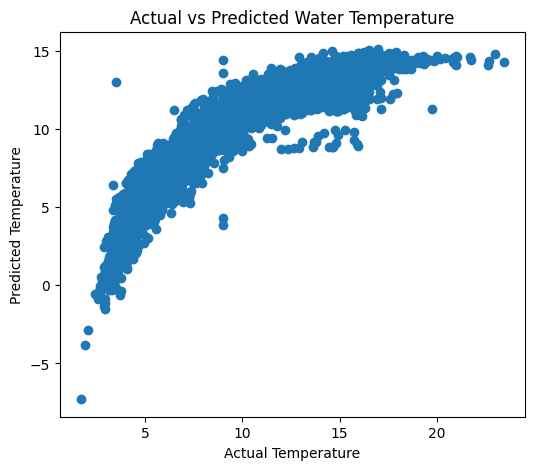

In [ ]:
# Actual vs Predicted

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Temperature")
plt.ylabel("Predicted Temperature")
plt.title("Actual vs Predicted Water Temperature")
plt.show()


Text(0.5, 1.0, 'Residual Error Distribution')

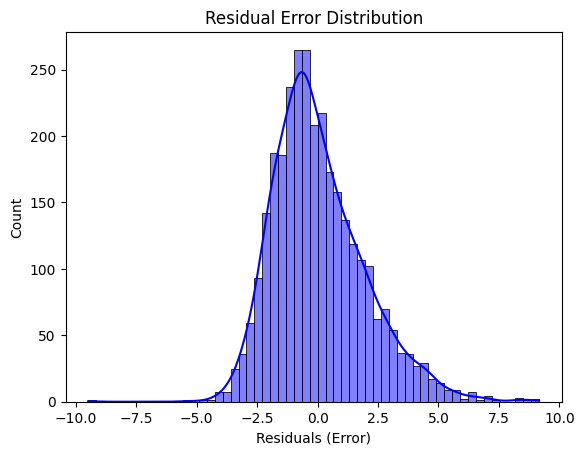

In [ ]:
# Residual Errors
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, color='blue')
plt.xlabel('Residuals (Error)')
plt.title('Residual Error Distribution')


Text(0.5, 1.0, 'Actual vs Predicted Temperature')

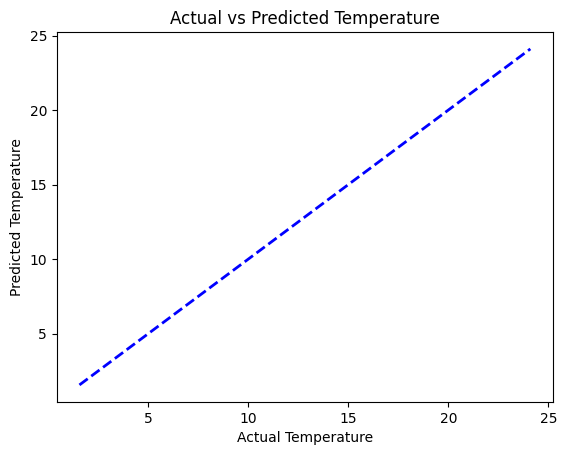

In [ ]:
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'b--', lw=2) # Identity line
plt.xlabel('Actual Temperature')
plt.ylabel('Predicted Temperature')
plt.title('Actual vs Predicted Temperature')

In [ ]:
# Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)
print("\nRidge RMSE:", np.sqrt(mean_squared_error(y_test, ridge_pred)))
print("Ridge R²:", r2_score(y_test, ridge_pred))



Ridge RMSE: 1.909731904709614
Ridge R²: 0.8030744420585388


In [ ]:
# Lasso Regression

lasso = Lasso(alpha=0.01)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)
print("\nLasso RMSE:", np.sqrt(mean_squared_error(y_test, lasso_pred)))
print("Lasso R²:", r2_score(y_test, lasso_pred))


Lasso RMSE: 2.378574085479176
Lasso R²: 0.7285059535669246


**SCENARIO 2:** Classify whether LIC stock price will increase (1) or decrease (0) based on historical data. Dataset (Kaggle – Public): https://www.kaggle.com/datasets/debashis74017/lic-stock-price-data Target Variable (Derived): • Price Movement – 1 → Closing price > Opening price – 0 → Closing price ≤ Opening price Input Features: • Open • High • Low • Volume

IN-LAB TASKS (Logistic Regression) • Import required Python libraries. • Load LIC stock dataset into Pandas. • Create a binary target variable (Price Movement). • Handle missing values. • Perform feature scaling. • Split the dataset into training and testing sets. • Train a Logistic Regression model. • Predict stock movement for test data. • Evaluate classification performance using: – Accuracy – Precision – Recall – F1-Score – Confusion Matrix • Visualize: – ROC Curve – Feature importance • Optimize model using: – Hyperparameter tuning (C, penalty) – Regularization



In [ ]:
df = pd.read_csv("/content/LICI - 10 minute data.csv")


In [ ]:
print("24BAD130 Vishal S")
df.head()

24BAD130 Vishal S


,date,open,high,low,close,volume
0,2022-05-17 09:35:00+05:30,872.00,872.00,872.0,872.00,3759243
1,2022-05-17 09:45:00+05:30,872.00,872.00,872.0,872.00,0
2,2022-05-17 09:55:00+05:30,872.00,918.10,862.0,902.80,12449251
3,2022-05-17 10:05:00+05:30,902.45,908.95,896.0,902.15,5237329
4,2022-05-17 10:15:00+05:30,902.30,905.00,900.0,903.85,1820317


In [ ]:
df.tail()

,date,open,high,low,close,volume
3679,2022-10-13 14:45:00+05:30,611.50,612.00,611.25,611.85,11190
3680,2022-10-13 14:55:00+05:30,611.75,611.95,611.55,611.85,15446
3681,2022-10-13 15:05:00+05:30,611.60,611.95,611.30,611.40,24264
3682,2022-10-13 15:15:00+05:30,611.60,612.00,611.05,611.60,41148
3683,2022-10-13 15:25:00+05:30,611.60,611.80,611.20,611.50,15685


In [ ]:
df.describe()

,open,high,low,close,volume
count,3684.000000,3684.000000,3684.000000,3684.000000,3.684000e+03
mean,694.709718,695.575679,693.738871,694.598588,7.014561e+04
std,63.481439,63.755377,63.166795,63.428558,2.639151e+05
min,611.400000,611.800000,611.000000,611.250000,0.000000e+00
25%,658.275000,659.500000,657.250000,658.125000,1.659125e+04
50%,676.225000,677.000000,675.375000,676.125000,3.025700e+04
75%,699.850000,700.612500,699.000000,699.800000,6.085100e+04
max,903.850000,918.100000,900.000000,903.850000,1.244925e+07


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3684 entries, 0 to 3683
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    3684 non-null   object 
 1   open    3684 non-null   float64
 2   high    3684 non-null   float64
 3   low     3684 non-null   float64
 4   close   3684 non-null   float64
 5   volume  3684 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 172.8+ KB


In [ ]:
df.isnull().sum()

,0
date,0
open,0
high,0
low,0
close,0
volume,0


In [ ]:
df['Target'] = (df['close'].shift(-1) > df['close']).astype(int)
df_model = df.drop(['date'], axis=1).dropna()

X = df_model.drop('Target', axis=1)
y = df_model['Target']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=False)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# Train Logistic Regression
model = LogisticRegression(C=100, penalty='l2', solver='liblinear', max_iter=5000)
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# Metrics
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")



Accuracy:  0.5889
Precision: 0.8667
Recall:    0.0414
F1-Score:  0.0790


Text(0.5, 1.0, 'Confusion Matrix')

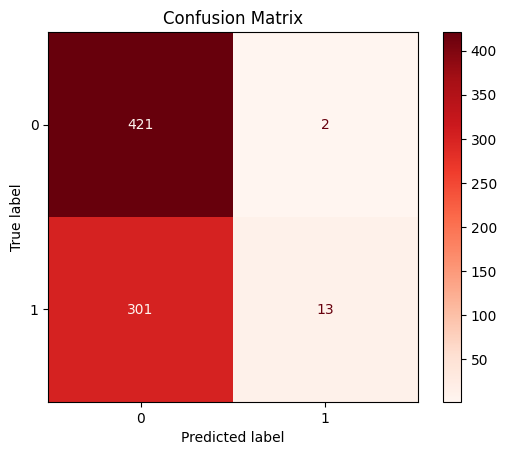

In [ ]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Reds')
plt.title("Confusion Matrix")

Text(0.5, 1.0, 'Receiver Operating Characteristic')

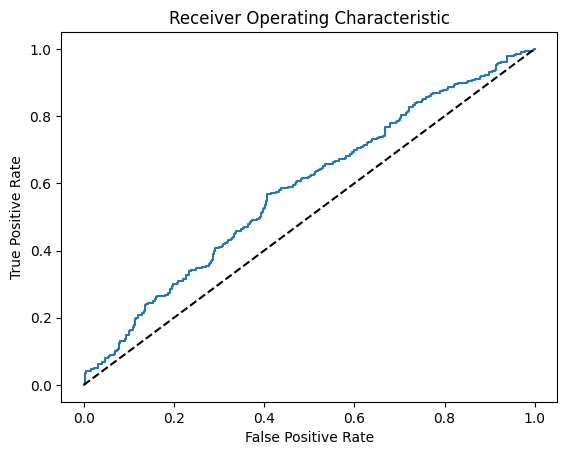

In [ ]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')

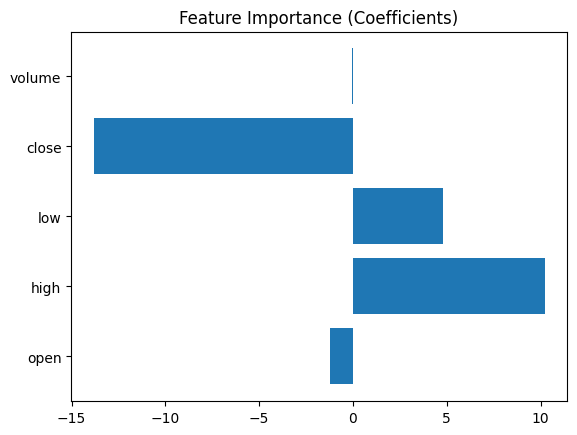

In [ ]:
importance = model.coef_[0]
features = X.columns
plt.barh(features, importance)
plt.title("Feature Importance (Coefficients)")
plt.show()

In [ ]:
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

grid_search = GridSearchCV(LogisticRegression(max_iter=5000), param_grid, cv=5, scoring='f1')
grid_search.fit(X_train_scaled, y_train)

best_model = grid_search.best_estimator_
print(f"Best Parameters: {grid_search.best_params_}")

Best Parameters: {'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}
